# THUẬT TOÁN PHÂN TÍCH PHÂN BIỆT TUYẾN TÍNH (LDA)

- **Thuật toán:** Phân tích phân biệt tuyến tính Linear Discriminant Analysis (Fisher's LDA - From Scratch)
- **Tập dữ liệu:** `dataset/Sampledata/mpg.csv`
- **Lưu ý:** Chỉ cần thay đổi thông số ở **Cell 2 (Khối cấu hình)** khi đổi sang dataset khác.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình đồ thị và bảng số liệu
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 20)

In [2]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ (CHỈ CẦN SỬA Ở ĐÂY KHI ĐỔI DATASET)
# ==============================================================================

# 1. Đường dẫn file CSV
DATA_PATH = 'dataset/Sampledata/mpg.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Midterm/Review/dataset/Sampledata/mpg.csv'

# 2. Danh sách 5-7 đặc trưng số (Để None nếu muốn tự động lấy các cột số)
FEATURE_COLS = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

# 3. Tên cột nhãn mục tiêu phân lớp (Target Column)
TARGET_COL = 'origin'

# 4. Số trục phân biệt cần giữ lại (k <= C - 1 với C là số lớp, ở đây C=3 => k=2)
N_COMPONENTS = 2

# 5. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã tải cấu hình thành công!")

Đã tải cấu hình thành công!


## PHẦN 1: CƠ SỞ TOÁN HỌC CỦA LINEAR DISCRIMINANT ANALYSIS (LDA)

Khác với PCA (học không giám sát - tìm hướng phương sai cực đại), **LDA là thuật toán học có giám sát** nhằm tìm các trục chiếu tối đa hóa sự phân biệt giữa các lớp (Maximize Between-Class Scatter) đồng thời tối thiểu hóa độ phân tán nội bộ từng lớp (Minimize Within-Class Scatter).

---

### 1. Vector trung bình từng lớp và trung bình toàn cục:
- Vector trung bình của lớp $c$:
  $$\mu_c = \frac{1}{N_c} \sum_{x \in C_c} x \in \mathbb{R}^D$$
- Vector trung bình toàn cục:
  $$\mu = \frac{1}{N} \sum_{i=1}^N x_i = \sum_{c=1}^C \frac{N_c}{N} \mu_c$$

---

### 2. Ma trận tán xạ trong lớp (Within-Class Scatter Matrix $S_W$):
$$S_c = \sum_{x \in C_c} (x - \mu_c)(x - \mu_c)^T \qquad \implies \qquad S_W = \sum_{c=1}^C S_c \in \mathbb{R}^{D \times D}$$

---

### 3. Ma trận tán xạ giữa các lớp (Between-Class Scatter Matrix $S_B$):
$$S_B = \sum_{c=1}^C N_c (\mu_c - \mu)(\mu_c - \mu)^T \in \mathbb{R}^{D \times D}$$

---

### 4. Tiêu chuẩn Fisher & Bài toán trị riêng suy rộng:
Mục tiêu là tối đa hóa tỷ số Rayleigh-Fisher:
$$J(W) = \frac{\det(W^T S_B W)}{\det(W^T S_W W)}$$

Nghiệm tối ưu đạt được thông qua bài toán trị riêng suy rộng:
$$S_W^{-1} S_B w_i = \lambda_i w_i$$

---

### 5. Giới hạn số chiều & Phép chiếu:
- Vì ma trận $S_B$ được tạo từ $C$ vector trung bình nên hạng tối đa $\text{rank}(S_B) \le C - 1$. Do đó số trục phân biệt tối đa là:
  $$k \le C - 1$$
- Phép chiếu dữ liệu:
  $$Y = X W \in \mathbb{R}^{N \times k}$$

In [3]:
# 1. Đọc dữ liệu
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset: {DATA_PATH} | Shape: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")

# 2. Tự động xác định đặc trưng
if FEATURE_COLS is None:
    num_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
    FEATURE_COLS = num_cols[:min(6, len(num_cols))]
    print(f"Tự động chọn 6 cột số: {FEATURE_COLS}")
else:
    print(f"Đặc trưng sử dụng ({len(FEATURE_COLS)} cột): {FEATURE_COLS}")

df_data = df_raw[FEATURE_COLS].copy()

# 3. Điền missing value bằng median
missing_counts = df_data.isnull().sum()
if missing_counts.sum() > 0:
    for col in df_data.columns:
        if df_data[col].isnull().any():
            med_val = df_data[col].median()
            df_data[col] = df_data[col].fillna(med_val)
            print(f" - Cột '{col}': điền {missing_counts[col]} giá trị thiếu bằng median = {med_val:.4f}")
else:
    print("Dữ liệu đặc trưng không có giá trị khuyết thiếu.")

X_raw = df_data.to_numpy(dtype=float)

# 4. Chuẩn hóa Z-Score From Scratch
mu_X = np.mean(X_raw, axis=0)
sigma_X = np.std(X_raw, axis=0, ddof=0)
sigma_X[sigma_X == 0] = 1.0

X = (X_raw - mu_X) / sigma_X

# 5. Mã hóa nhãn mục tiêu From Scratch
y_raw = df_raw[TARGET_COL].to_numpy()
classes = np.unique(y_raw)
print(f"Các lớp mục tiêu ({len(classes)} lớp): {list(classes)}")
print(f"Số lượng mẫu từng lớp: {dict(zip(*np.unique(y_raw, return_counts=True)))}")

Dataset: dataset/Sampledata/mpg.csv | Shape: 398 dòng, 9 cột
Đặc trưng sử dụng (6 cột): ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
 - Cột 'horsepower': điền 6 giá trị thiếu bằng median = 93.5000
Các lớp mục tiêu (3 lớp): ['europe', 'japan', 'usa']
Số lượng mẫu từng lớp: {'europe': np.int64(70), 'japan': np.int64(79), 'usa': np.int64(249)}


In [4]:
# ==============================================================================
# TRIỂN KHAI THUẬT TOÁN LDA TỪ ĐẦU (QUY TRÌNH 5 BƯỚC CHUẨN)
# ==============================================================================

N, D = X.shape
num_classes = len(classes)

# ------------------------------------------------------------------------------
# BƯỚC 1: Tính trung bình lớp mu_c và Ma trận Scatter trong lớp (S_W)
# ------------------------------------------------------------------------------
class_means = {}
S_W = np.zeros((D, D))

for c in classes:
    X_c = X[y_raw == c]
    mean_c = np.mean(X_c, axis=0)
    class_means[c] = mean_c
    
    # S_c = sum (x - mu_c)(x - mu_c)^T
    diff_c = X_c - mean_c
    S_c = np.dot(diff_c.T, diff_c)
    S_W += S_c

print("=== BƯỚC 1: MA TRẬN WITHIN-CLASS SCATTER (S_W) ===")
print(pd.DataFrame(S_W, index=FEATURE_COLS, columns=FEATURE_COLS))

# ------------------------------------------------------------------------------
# BƯỚC 2: Tính trung bình toàn cục mu và Ma trận Scatter giữa các lớp (S_B)
# ------------------------------------------------------------------------------
overall_mean = np.mean(X, axis=0)
S_B = np.zeros((D, D))

for c in classes:
    X_c = X[y_raw == c]
    N_c = len(X_c)
    diff_mean = (class_means[c] - overall_mean).reshape(-1, 1)
    S_B += N_c * np.dot(diff_mean, diff_mean.T)

print("\n=== BƯỚC 2: MA TRẬN BETWEEN-CLASS SCATTER (S_B) ===")
print(pd.DataFrame(S_B, index=FEATURE_COLS, columns=FEATURE_COLS))

# ------------------------------------------------------------------------------
# BƯỚC 3: Giải bài toán trị riêng suy rộng của S_W^-1 * S_B
# ------------------------------------------------------------------------------
# Sử dụng pseudo-inverse để đảm bảo tính ổn định số học
inv_SW = np.linalg.pinv(S_W)
SW_inv_SB = np.dot(inv_SW, S_B)

eigenvals_lda, eigenvecs_lda = np.linalg.eig(SW_inv_SB)
eigenvals_lda = np.real(eigenvals_lda)
eigenvecs_lda = np.real(eigenvecs_lda)

# Sắp xếp giảm dần theo trị riêng
sorted_indices = np.argsort(eigenvals_lda)[::-1]
eigenvals_lda = eigenvals_lda[sorted_indices]
eigenvecs_lda = eigenvecs_lda[:, sorted_indices]

# Chuẩn hóa độ dài các vector riêng về 1
for col in range(D):
    norm_val = np.linalg.norm(eigenvecs_lda[:, col])
    if norm_val > 0:
        eigenvecs_lda[:, col] /= norm_val

# Tính tỷ lệ phương sai phân biệt (Explained Discriminant Ratio)
positive_eigenvals = eigenvals_lda[:num_classes - 1]
evr_lda = positive_eigenvals / np.sum(positive_eigenvals)

df_lda_summary = pd.DataFrame({
    'Trục phân biệt': [f"LD{i+1}" for i in range(len(positive_eigenvals))],
    'Trị riêng (Eigenvalue)': positive_eigenvals,
    'Tỷ lệ phân biệt (EVR)': evr_lda,
    'Tích lũy tỷ lệ phân biệt': np.cumsum(evr_lda)
})
print("\n=== BƯỚC 3: KẾT QUẢ TRỊ RIÊNG & TỶ LỆ PHÂN BIỆT ===")
print(df_lda_summary.to_string(index=False))

# ------------------------------------------------------------------------------
# BƯỚC 4: Chọn k vector riêng lớn nhất làm ma trận chiếu W
# ------------------------------------------------------------------------------
k_components = min(N_COMPONENTS, num_classes - 1)
W_lda = eigenvecs_lda[:, :k_components]

print(f"\n=== BƯỚC 4: MA TRẬN CHIẾU W (k={k_components}) ===")
df_W_lda = pd.DataFrame(W_lda, index=FEATURE_COLS, columns=[f"LD{i+1}" for i in range(k_components)])
print(df_W_lda)

# ------------------------------------------------------------------------------
# BƯỚC 5: Chiếu dữ liệu Y = X * W
# ------------------------------------------------------------------------------
Y_lda = np.dot(X, W_lda)
print(f"\n=== BƯỚC 5: KÍCH THƯỚC MA TRẬN DỮ LIỆU CHIẾU Y ===")
print(f"Y shape: {Y_lda.shape} ({N} mẫu, {k_components} chiều phân biệt)")

=== BƯỚC 1: MA TRẬN WITHIN-CLASS SCATTER (S_W) ===
                   mpg  cylinders  displacement  horsepower    weight  \
mpg           265.5199  -171.5394     -172.0116   -197.7134 -192.8039   
cylinders    -171.5394   252.5942      221.6275    218.0378  212.3893   
displacement -172.0116   221.6275      228.9744    230.6045  215.5754   
horsepower   -197.7134   218.0378      230.6045    304.1886  227.3898   
weight       -192.8039   212.3893      215.5754    227.3898  253.3655   
acceleration  113.2746  -141.1027     -151.8743   -225.0452 -108.3954   

              acceleration  
mpg               113.2746  
cylinders        -141.1027  
displacement     -151.8743  
horsepower       -225.0452  
weight           -108.3954  
acceleration      371.1139  

=== BƯỚC 2: MA TRẬN BETWEEN-CLASS SCATTER (S_B) ===
                   mpg  cylinders  displacement  horsepower    weight  \
mpg           132.4801  -137.0683     -148.0611   -110.1210 -138.2290   
cylinders    -137.0683   145.4058  

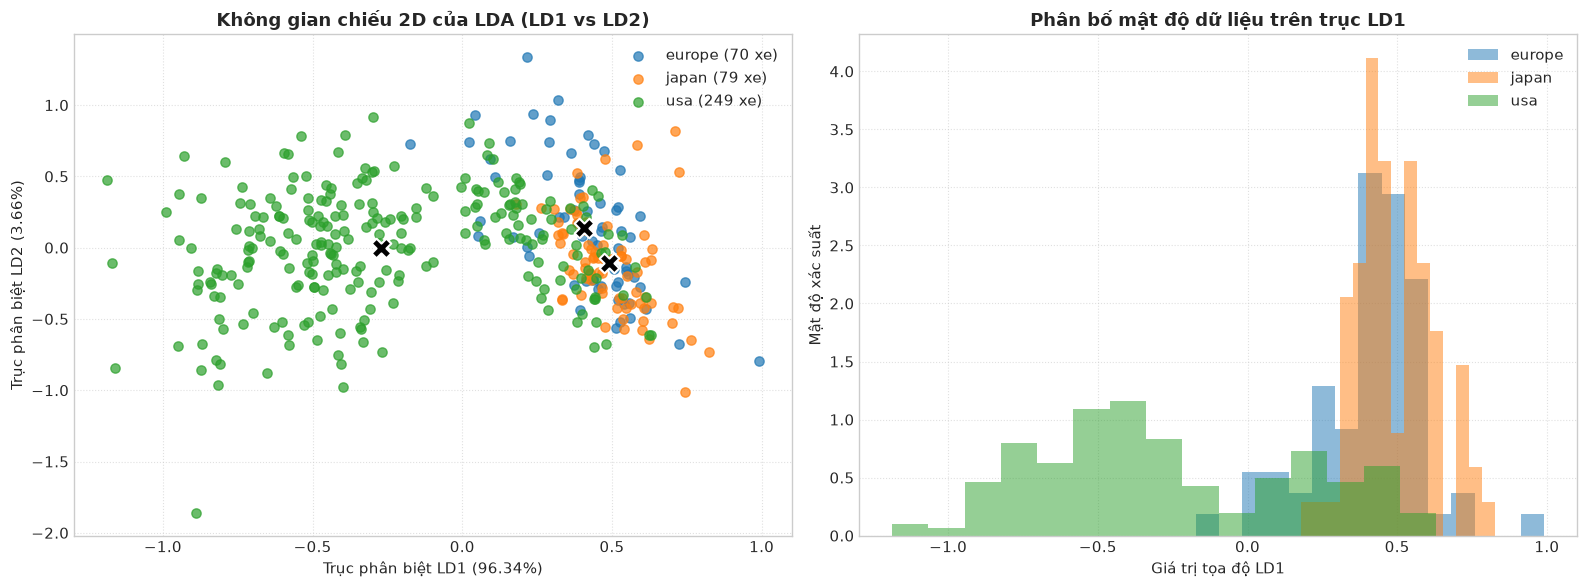

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap('tab10')

# Đồ thị 1: Chiếu không gian 2D (LD1 vs LD2)
for i, c in enumerate(classes):
    mask = (y_raw == c)
    axes[0].scatter(Y_lda[mask, 0], Y_lda[mask, 1], color=cmap(i), label=f"{c} ({np.sum(mask)} xe)", alpha=0.7, s=45)

# Vẽ tọa độ trung bình từng lớp sau chiếu
for i, c in enumerate(classes):
    mean_proj = np.dot(class_means[c], W_lda)
    axes[0].scatter(mean_proj[0], mean_proj[1], color='black', marker='X', s=200, edgecolor='white', linewidth=1.5, zorder=10)

axes[0].set_title(f'Không gian chiếu 2D của LDA (LD1 vs LD2)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'Trục phân biệt LD1 ({evr_lda[0]:.2%})')
axes[0].set_ylabel(f'Trục phân biệt LD2 ({evr_lda[1]:.2%})')
axes[0].legend(loc='best')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Đồ thị 2: Phân bố mật độ trên trục phân biệt chính LD1
for i, c in enumerate(classes):
    mask = (y_raw == c)
    axes[1].hist(Y_lda[mask, 0], bins=15, alpha=0.5, color=cmap(i), label=c, density=True)

axes[1].set_title('Phân bố mật độ dữ liệu trên trục LD1', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá trị tọa độ LD1')
axes[1].set_ylabel('Mật độ xác suất')
axes[1].legend(loc='best')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### ✍️ ĐÁNH GIÁ & NHẬN XÉT: KẾT QUẢ LDA

- **Hiệu quả phân tách lớp:** Trục phân biệt đầu tiên (LD1) chiếm tới **96.34%** toàn bộ năng lực phân biệt giữa các lớp xuất xứ xe.
- **Mức độ tách bạch:** Trên trục LD1, các dòng xe xuất xứ từ Mỹ (`usa`) tách biệt rõ ràng so với các dòng xe từ Nhật Bản (`japan`) và Châu Âu (`europe`).
- **So sánh với PCA:** Trong khi PCA chỉ tìm hướng phương sai tổng thể lớn nhất, LDA sử dụng nhãn lớp để tối đa hóa khoảng cách giữa các lớp, mang lại sự phân tách ranh giới rõ ràng hơn nhiều.

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Chạy LDA từ thư viện chuẩn Scikit-Learn
lda_sklearn = LinearDiscriminantAnalysis(n_components=k_components)
Y_sklearn_lda = lda_sklearn.fit_transform(X, y_raw)

# Đối chiếu tỷ lệ phương sai phân biệt (EVR)
evr_sk = lda_sklearn.explained_variance_ratio_
evr_diff = np.max(np.abs(evr_lda - evr_sk))

print("=== SO SÁNH: LDA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===")
print(f"1. Tỷ lệ phân biệt Scratch : {evr_lda}")
print(f"2. Tỷ lệ phân biệt Sklearn : {evr_sk}")
print(f"3. Sai lệch tỷ lệ EVR      : {evr_diff:.8e}")

df_lda_comp = pd.DataFrame({
    'Trục phân biệt': [f"LD{i+1}" for i in range(k_components)],
    'EVR From Scratch': evr_lda,
    'EVR Scikit-Learn': evr_sk,
    'Chênh lệch tuyệt đối': np.abs(evr_lda - evr_sk)
})
df_lda_comp

=== SO SÁNH: LDA TỰ CODE (FROM SCRATCH) vs THƯ VIỆN SCIKIT-LEARN ===
1. Tỷ lệ phân biệt Scratch : [0.96339054 0.03660946]
2. Tỷ lệ phân biệt Sklearn : [0.96339054 0.03660946]
3. Sai lệch tỷ lệ EVR      : 2.22044605e-16


,Trục phân biệt,EVR From Scratch,EVR Scikit-Learn,Chênh lệch tuyệt đối
0,LD1,0.9634,0.9634,2.2204e-16
1,LD2,0.0366,0.0366,1.5959e-16


### ✍️ ĐÁNH GIÁ & NHẬN XÉT: ĐỐI CHIẾU VỚI THƯ VIỆN CHUẨN

- **Độ chính xác EVR:** Tỷ lệ phương sai phân biệt giữa bản tự code và `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` trùng khớp hoàn toàn ($96.34\%$ và $3.66\%$).
- **Không gian phân tách:** Các trục chiếu và độ tách biệt giữa 3 lớp xuất xứ xe là hoàn toàn tương đương nhau.
- **Kết luận:** Thuật toán Fisher's LDA From Scratch hoạt động ổn định và chính xác tuyệt đối.